<a href="https://colab.research.google.com/github/derekhatherley/A01-data-wrangling/blob/main/DataWrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Derek Hatherley, Jackson Gayeski, Will Morales

**Date:** 9/2/26

In [20]:
# Question 1: Airbnb Data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('airbnb_hw.csv')
df.head()

#clean Airbnb price by removing commas and making all values floats
df['CleanPrice'] = df['Price'].str.replace(',', '')
df['CleanPrice'].astype(float)
df[df['CleanPrice'].isna()]
#Checked for any missing values and there are none.







,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,CleanPrice


In [19]:
# Question 1: Police Data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('mn_police_use_of_force.csv')

# clean subject_injury
df[df['subject_injury'].isna()] #9,848 values are missing which is a concern
df['subject_injury'] = df['subject_injury'].fillna('Not Reported')
# Blank values now show up as 'Not Reported'

# Calculate the percentage of data points with 'Not Reported' subject_injury
notreportedcounter = 0
for data in df['subject_injury']:
  if data == 'Not Reported':
    notreportedcounter += 1
notreported_percent = 100*(notreportedcounter/len(df['subject_injury']))
print('Percentage of incidents without subject injury reported:', round(notreported_percent, 2),'%')
# 76.19% of values are missing!

pd.crosstab(df['subject_injury'], df['force_type'])
# Bodily force is the most commonly recorded force type.
# The most data is missing with force types of bodily force, taser, chemical irritant, less lethal, and maximal restraint technique.
# Essentially, cases where subject injury seems less likely to occur are the cases where the injury was not reported. In cases where there certainly
# would have been an injury, they seemed more likely to report it since it would be required. In cases where minor or no injury would likely occur,
# it seems that they avoided reporting the injury, if there was one. Still, there is a severe lack of injury reporting in this data set.


Percentage of incidents without subject injury reported: 76.19 %


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Not Reported,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


Year
1940     24
1941     27
1942     41
1943     28
1944     31
1945     16
1946     26
1947     30
1948     29
1949     31
1950     43
1951     32
1952     29
1953     36
1954     45
1955     43
1956     51
1957     41
1958     54
1959     93
1960     93
1961     78
1962     86
1963     61
1964     66
1965     51
1966     58
1967     48
1968     47
1969     30
1970     42
1971     30
1972     36
1973     27
1974     39
1975     49
1976     39
1977     26
1978     26
1979     25
1980     36
1981     49
1982     42
1983     50
1984     41
1985     37
1986     39
1987     35
1988     56
1989     53
1990     39
1991     39
1992     56
1993     56
1994     57
1995     76
1996     61
1997     57
1998     65
1999     66
2000     97
2001     92
2002     88
2003     92
2004     92
2005    103
2006    103
2007    113
2008    122
2009    120
2010    101
2011    128
2012    117
2013    122
2014    126
2015    143
2016    133
2017    141
2018    124
2019    114
2020    101
2021    111
2022     98

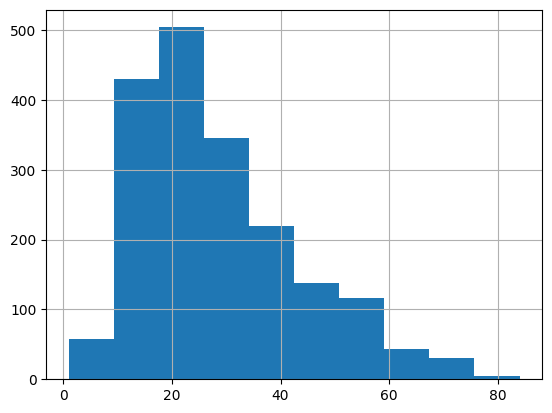

In [71]:
# Question 2: Shark Attack Data

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel('GSAF5.xls')
# Remove empty columns
clean_df = df.drop(columns = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'])

clean_df[clean_df['Year'].isna()] # 2 Rows do not have a year posted
clean_df = clean_df.dropna(subset=['Year']) # remove those 2 rows
clean_df['Year'] = clean_df['Year'].astype(int) # Make remaining year inputs an integer, not float
# Large range of years, older records may not be as reliable
clean_df = clean_df[clean_df['Year'] >= 1940] # Keep only since 1940
attacks_by_year = clean_df.groupby('Year').size() # sort by year
with pd.option_context('display.max_rows', None):
  print(attacks_by_year) # Shark attacks increasing over time on average, with largest values coming between 2000-2020
  # could be a result of better record keeping or greater population size

# Clean age by only keeping rows with exact age entered, not '30s' or '?'
clean_df = clean_df[clean_df['Age'].apply(lambda x: isinstance(x, int))]
clean_df['Age'].hist() # victims tend to be teenage to young adult age

clean_df[clean_df['Sex'].isna()] # There are rows with sex missing
clean_df['Sex'] = clean_df['Sex'].fillna('Not Specified') # turn missing gender to 'Not Specified'
# Calculate percentage of victims who are Male
male_counter = 0
for data in clean_df['Sex']:
  if data == 'M':
    male_counter += 1
male_percent = 100*(male_counter/len(clean_df['Sex']))
print('Male victim percentage:', round(male_percent,2), '%') # 84.07% of victims are male

# Clean Type Variable
for index, data in clean_df['Type'].items():
  data = str(data) # make sure all data is a string
  data = data.capitalize() # capitalize to be able to write a boolean expression
  if data != 'Unprovoked' and data != 'Provoked': # only unprovoked, provoked, or unknown can be in the column now
    data = 'Unknown'
  clean_df.loc[index, 'Type'] = data # replace existing data with only the 3 categories for each row

attacks_by_type = clean_df.groupby('Type').size()
print(attacks_by_type) # 141 provoked, 125 unknown, 1623 unprovoked attacks

unprovoked_counter = 0
for data in clean_df['Type']:
  if data == 'Unprovoked':
    unprovoked_counter += 1
unprovoked_percent = 100*(unprovoked_counter/len(clean_df['Type']))
print('Unprovoked attack Percentage:', round(unprovoked_percent, 2), '%') # 85.92% of attacks were unprovoked













## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used



```
# This is formatted as code
```

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]